# Type Ia Supernova Distance — Progressive Build

A step-by-step distance pipeline for a Type Ia supernova, built the same
way as `variable_star_distance.ipynb`: explain the physics, then build the
code that implements it, one stage at a time, against real observations.
The two notebooks share the same underlying distance-modulus math -- what
differs is how the absolute magnitude $M$ gets estimated in the first
place.

Built in three parts, deliberately: **Part 1** is the classical
Phillips/Hamuy decline-rate method (the approach SN Ia cosmology actually
used through the 1990s); **Part 2** is the modern SALT2 light-curve fit
with literature-calibrated Tripp-estimator nuisance parameters; **Part 3**
compares the two against each other (and a rough Hubble-law cross-check).
Seeing both side by side, on the same raw data, is the point -- not just
arriving at today's best answer.


## The Physics: From Flux to Distance

Every distance measurement here traces back to one relationship: how bright
an object appears depends on how much light it puts out and how far away it
is.

**Flux and luminosity.** A source radiates a total luminosity $L$ (energy
per second) equally in all directions. At distance $d$, that light has
spread out over the surface of a sphere of area $4\pi d^2$, so the flux $f$
(energy per second, per unit area) we receive is:

$$ f = \frac{L}{4\pi d^2} $$

This is the inverse-square law: flux falls off as the square of distance —
double the distance, receive a quarter of the light — regardless of what
kind of object it is.

**From flux to magnitudes.** Astronomical magnitudes are a logarithmic flux
scale (Pogson's law): $m = -2.5\log_{10}(f) + \text{const}$. Compare the
object's actual apparent magnitude $m$ (its flux $f$ at its real distance
$d$) to its absolute magnitude $M$ (the magnitude it *would* have if placed
at the standard reference distance of 10 pc, flux $F_{10}$):

$$ m - M = -2.5\log_{10}\!\left(\frac{f}{F_{10}}\right) $$

Since $f \propto 1/d^2$ (from above) and $F_{10} \propto 1/(10\,\mathrm{pc})^2$,
the luminosity $L$ cancels out of the ratio $f/F_{10}$ entirely, leaving
only distance:

$$ \frac{f}{F_{10}} = \left(\frac{10\,\mathrm{pc}}{d}\right)^{\!2}
   \quad\Longrightarrow\quad m - M = 5\log_{10}(d) - 5 $$

This is the **distance modulus**. Solved for distance (in parsecs):

$$ d = 10^{\,(m - M + 5)/5} $$

$m$ is measurable directly — point a telescope at the object and measure
its flux. $M$ is the problem: it's a property of the object itself, not of
us, and nothing about observing its *apparent* brightness tells you how far
away it is without already knowing $M$. This is exactly the same problem
`variable_star_distance.ipynb` solves for pulsating variables via a
period–luminosity relation; here it gets solved a different way.


## The Challenge of Measuring Luminosity

You can't point a telescope at a supernova and read off its luminosity or
absolute magnitude directly — what you measure is flux, and the
inverse-square law above shows flux depends on *both* luminosity and
distance at once.

**Why Type Ia supernovae are close to standard candles in the first
place.** A Type Ia arises when a white dwarf's mass approaches the
Chandrasekhar limit (~1.4 solar masses) — whether by accreting material
from a companion star or merging with one — and the whole star detonates in
a thermonuclear runaway. Because that trigger mechanism is fairly
consistent from event to event, the peak luminosity is too: unlike the
pulsating variables in `variable_star_distance.ipynb`, whose luminosity
depends on stellar mass, radius, and evolutionary state (hence a whole
family of different period–luminosity relations by class), Type Ia SNe are
close to *one* standard candle already, before any correction at all.

**Why "close to standard" still isn't standard enough.** Even among Type Ia
events, peak luminosity varies — some SNe Ia are intrinsically brighter than
others. Phillips (1993) found the key regularity: **peak brightness
correlates with how fast the light curve declines afterward.** Slower
decliners are intrinsically brighter, faster decliners intrinsically
fainter — a single-parameter correction (traditionally $\Delta m_{15}(B)$,
the drop in B-band magnitude from peak to 15 days later) that turns "close
to standard" into "standardizable." This plays the same structural role
here that a period–luminosity relation plays for pulsating variables: an
observable light-curve property standing in for an $M$ that can't be
measured directly.

**What this notebook still needs to pin down.** The general shape of the
brightness-decline relation is well established, but the exact calibration
— the zero-point absolute magnitude at a "normal" decline rate, and the
slope of the correction — varies across the literature depending on the
calibration sample and adopted distance scale. Rather than guess a number,
this notebook sources that calibration properly once we reach the
absolute-magnitude step below, the same way `variable_star_distance.ipynb`
only ever added a period–luminosity relation once it had a citable
reference for it.


## What This Notebook Needs

Given a calibrated brightness-decline relation to stand in for the $M$ we
can't measure directly, here's how this notebook gets from observations to
a distance.

**Where the data comes from.** `REPORT_PATH` (in Configuration below)
points at photometry for the supernova, downloaded from the AAVSO
International Database (AID) — the same download format
`variable_star_distance.ipynb` already has a working loader for, since it's
the same AAVSO export regardless of what kind of object it covers.

**The chain, start to finish.**

1. **Observations** — (time, magnitude) pairs extracted from the report,
   covering the SN's rise, peak, and decline.
2. **$m_{\text{max}}$** (peak apparent magnitude) and **decline rate** —
   both found by fitting the light curve's shape near maximum light,
   *not* by folding on a period the way a pulsating variable is (a
   supernova doesn't repeat).
3. **$M$** (absolute magnitude at peak) — computed from the decline rate
   via the brightness-decline relation, since $M$ itself can't be measured
   directly (previous section).
4. **$d$** (distance) — computed from $m_{\text{max}}$ and $M$ via the same
   distance modulus as before.

| Quantity | Derived from |
|---|---|
| Observations | the AAVSO report |
| $m_{\text{max}}$, decline rate | the light curve's shape near peak |
| $M$ | decline rate, via the brightness-decline relation |
| $d$ | $m_{\text{max}}$ and $M$, via the distance modulus |

**The cross-check here, unlike `variable_star_distance.ipynb`.**
That notebook gets an independent check for free from Gaia's parallax to
the star itself -- a supernova is far too distant for that. The
cross-check here instead comes from Part 2 below: a completely different
standardization method (SALT2/Tripp) run against the same raw photometry,
compared in Part 3 alongside a rough, honestly-caveated Hubble-law
distance ($d=cz/H_0$) from the host's own redshift.


## 1 · Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("imports ok")

imports ok


## 2 · Configuration

Everything you'd change for a different report or band lives here — one
place to look before a run, rather than hunting through cells below.
`STAR_LABEL`/`HOST_GALAXY` aren't set here directly -- they're derived from
`REPORT_PATH`'s own filename via `KNOWN_TARGETS`, below.


In [2]:
# --- known targets: report filename -> (STAR_LABEL, HOST_GALAXY) ---------------
# Keyed by the report's own filename (not the full path), so this doesn't care
# where AAVSO-Downloads/ actually lives. Expand this as new reports are added --
# each host galaxy verified independently (git history, AAVSO/discovery notices,
# NED/SIMBAD) before being added here, not guessed. This table exists specifically
# to prevent the earlier NGC 3921-vs-3972 mixup (a wrong, similar-looking NGC
# number typed by hand fed a badly wrong redshift into every downstream lookup)
# from happening again.
KNOWN_TARGETS = {
    "2011by.csv": ("SN 2011by", "NGC 3972"),      # https://en.wikipedia.org/wiki/SN_2011by
    "2011fe.csv": ("SN 2011fe", "M101"),
    "2012fr.csv": ("SN 2012fr", "NGC 1365"),
    "2025rbs.csv": ("SN 2025rbs", "NGC 7331"),
    "2026aaiv.csv": ("SN 2026aaiv", "NGC 7331"),  # same host as 2025rbs -- confirmed (two
                                                    # separate SNe in NGC 7331 within ~14 months)
}

REPORT_PATH = "/Users/jwatts/Documents/astrophotography/Photometry/AAVSO-Downloads/2025rbs.csv"
BAND = "V"
TARGET_NAME = None          # only needed if the report covers more than one object
PEAK_FIT_WINDOW_DAYS = 15.0  # +/- window fit_peak/mag_at_time use around a candidate peak/query
                             # time -- the right value depends on how densely sampled the light
                             # curve is; fit_peak now raises rather than silently returning a bad
                             # answer if a window doesn't converge to a stable peak (e.g. because
                             # it's anchored on a single bad point), so a failure here means
                             # widening (sparser data) or narrowing (denser data, tighter peak)
                             # this value, not a bug to work around.

# STAR_LABEL and HOST_GALAXY are derived from REPORT_PATH's filename via KNOWN_TARGETS above,
# not set by hand here -- this is exactly what caused the NGC 3921-vs-3972 mixup: switching
# REPORT_PATH to a new star without also remembering to update HOST_GALAXY (or updating it to
# the wrong, similar-looking value). A filename not yet in the table raises immediately, rather
# than silently running with a stale or wrong host left over from a previous target.
_report_filename = Path(REPORT_PATH).name
if _report_filename not in KNOWN_TARGETS:
    raise KeyError(
        f"{_report_filename!r} isn't in KNOWN_TARGETS above -- add an entry "
        f"(STAR_LABEL, HOST_GALAXY) for it before running further sections. Verify the host "
        f"galaxy independently (AAVSO/discovery notice, NED, SIMBAD) before adding it, don't "
        f"guess -- see the 2011by/NGC 3921-vs-3972 mixup this table exists to prevent."
    )
STAR_LABEL, HOST_GALAXY = KNOWN_TARGETS[_report_filename]

print(f"REPORT_PATH = {REPORT_PATH}")
print(f"BAND = {BAND}, TARGET_NAME = {TARGET_NAME}, STAR_LABEL = {STAR_LABEL}")
print(f"PEAK_FIT_WINDOW_DAYS = {PEAK_FIT_WINDOW_DAYS}, HOST_GALAXY = {HOST_GALAXY}")

REPORT_PATH = /Users/jwatts/Documents/astrophotography/Photometry/AAVSO-Downloads/2025rbs.csv
BAND = V, TARGET_NAME = None, STAR_LABEL = SN 2025rbs
PEAK_FIT_WINDOW_DAYS = 15.0, HOST_GALAXY = NGC 7331


In [3]:
# --- decline rate -> absolute magnitude relations (width-luminosity relation) ---
# Registry of linear WLR relations (M_B = a + b*(dm15(B) - dm15_ref)). Add a new
# entry here to make it selectable via WLR_NAME below -- see Section 7 for the
# uncertainty model these fields feed into.
WLR_RELATIONS = {
    "Hamuy1996_B": {
        "label": "Type Ia SN, B-band width-luminosity relation (Hamuy et al. 1996)",
        "a": -19.258, "a_err": 0.048,    # absolute B mag at dm15_ref (H0 = 65 km/s/Mpc assumed)
        "b": 0.784, "b_err": 0.182,      # slope
        "dm15_ref": 1.1,                 # reference decline rate the zero-point is quoted at
        "sigma_intrinsic": 0.17,         # dispersion of the fit (mag) -- low-extinction subsample
        "reference": "Hamuy et al. (1996), M_B = a + b*(dm15(B) - 1.1), H0 = 65 km/s/Mpc assumed",
    },
}

WLR_NAME = "Hamuy1996_B"   # must be a key in WLR_RELATIONS above

print(f"WLR_NAME = {WLR_NAME} -> {WLR_RELATIONS[WLR_NAME]['label']}")

WLR_NAME = Hamuy1996_B -> Type Ia SN, B-band width-luminosity relation (Hamuy et al. 1996)


## 3 · Load an AAVSO report

Same AAVSO International Database (AID) CSV format `variable_star_distance.ipynb`
already parses — this is the same AAVSO export regardless of what kind of
object it covers, so the loader (including its column-name and band-label
normalization) is carried over unchanged rather than reinvented. See that
notebook's Section 3 markdown for the full detail on why detection and
normalization work the way they do; the short version:

- Detection tests for Extended Format's `#KEY=VALUE` first-line shape, not
  just a leading `#` (this AID export's own row-counter column is named
  `#`, which would otherwise misroute it).
- `AID_COLUMNS` / `AID_BAND_CODES` normalize this export's column names and
  full band labels (`Johnson V`, `Cousins R`, ...) onto the same
  `DATE`/`MAG`/`MERR`/`FILT`/`NAME` columns and short codes (`V`, `R`, ...)
  an Extended Format report would use.
- `fainterthan` (non-detection) rows are dropped before anything downstream
  sees them.


In [4]:
# AAVSO's AID export writes full band names ("Johnson V"); Extended Format
# writes the short FILT codes ("V"). Normalizing here means BAND in
# Configuration stays the same short code regardless of which source is
# loaded. Keys are lowercased for matching, since AID capitalization varies
# ("Tri-Color Green"). Anything not listed passes through unchanged, so an
# unrecognized band can still be selected by setting BAND to its raw label.
AID_BAND_CODES = {
    "johnson u": "U", "johnson b": "B", "johnson v": "V",
    "cousins r": "R", "cousins i": "I",
    "sloan u'": "SU", "sloan g'": "SG", "sloan r'": "SR",
    "sloan i'": "SI", "sloan z'": "SZ",
    "tri-color green": "TG", "tri-color blue": "TB", "tri-color red": "TR",
    "unfiltered with v zeropoint": "CV", "unfiltered with r zeropoint": "CR",
    "visual": "VISUAL",
}

# Column spellings seen across AID exports, keyed lowercase.
AID_COLUMNS = {
    "jd": "DATE",
    "mag": "MAG", "magnitude": "MAG",
    "uncertainty": "MERR",
    "band": "FILT",
    "target": "NAME", "star name": "NAME",
}


def load_aavso_report(path):
    """Parse AAVSO photometry from either source format, auto-detected, and
    normalized onto a common set of columns (NAME, DATE, MAG, MERR, FILT).
    """
    path = Path(path)
    first_line = next((l for l in path.read_text().splitlines() if l.strip()), "")
    # Extended Format's first line is a '#KEY=VALUE' parameter (the spec
    # mandates #TYPE=EXTENDED first). An AID CSV can start with '#' too --
    # its row-number column is literally named '#' -- so testing for '#'
    # alone misroutes it here; testing for the '#KEY=' shape doesn't.
    head, sep, _ = first_line.partition("=")
    if sep and head.startswith("#") and head[1:].strip().isalpha():
        return _load_extended_format(path)
    return _load_aid_download(path)


def _load_extended_format(path):
    """AAVSO Extended Format (VPhot/ASTAP export, transformed or not)."""
    delim = ","
    header = None
    data_lines = []

    for line in path.read_text().splitlines():
        if not line.strip():
            continue
        if line.startswith("#DELIM="):
            delim = line.split("=", 1)[1].strip()
        elif line.startswith("#NAME" + delim):
            header = line.lstrip("#").split(delim)
        elif line.startswith("#"):
            continue
        else:
            data_lines.append(line.split(delim))

    if header is None:
        raise ValueError(f"Could not find column header line in {path}")

    df = pd.DataFrame(data_lines, columns=header)
    for col in ["DATE", "MAG", "MERR"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def _load_aid_download(path):
    """A CSV downloaded from the AAVSO International Database. Its column
    names and band labels differ from the Extended Format export (and
    between AID exports themselves), so both are normalized here via
    AID_COLUMNS / AID_BAND_CODES -- everything downstream then works the
    same regardless of source."""
    df = pd.read_csv(path, low_memory=False)
    df = df.rename(columns={c: AID_COLUMNS.get(c.strip().lower(), c) for c in df.columns})

    if "FILT" in df.columns:
        df["FILT"] = df["FILT"].map(lambda b: AID_BAND_CODES.get(str(b).strip().lower(), b))

    for col in ["DATE", "MAG", "MERR"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # 'fainterthan' rows are non-detections (upper limits), not measurements --
    # averaging them into a light-curve fit would bias it faint.
    if "fainterthan" in df.columns:
        faint = df["fainterthan"].astype(str).str.strip().str.lower() == "true"
        if faint.any():
            print(f"  dropped {int(faint.sum())} 'fainter than' (non-detection) rows")
            df = df.loc[~faint]

    return df


def get_band_series(df, band, target_name=None):
    """Time (JD) and magnitude arrays for one filter, sorted and cleaned.
    `target_name` narrows to one object if the report covers more than one.
    """
    sel = df["FILT"] == band
    if target_name is not None:
        sel &= df["NAME"] == target_name
    d = df.loc[sel].dropna(subset=["DATE", "MAG"]).sort_values("DATE")
    meta = {
        "target": target_name or (df["NAME"].iloc[0] if len(df) else None),
        "band": band,
        "n_points": len(d),
    }
    return d["DATE"].to_numpy(), d["MAG"].to_numpy(), meta


def plot_raw_data(times, mags, title):
    """Magnitude vs. time for the loaded band -- a first look at the raw
    observations, so the rise, peak, and decline are visible by eye up
    front."""
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(times, mags, s=10, alpha=0.5, color="steelblue")
    ax.invert_yaxis()
    ax.set(xlabel="time (JD)", ylabel="magnitude", title=title)
    fig.tight_layout()
    return fig, ax


def bin_by_day(times, mags):
    """Nightly-mean (times, mags) -- found necessary empirically: a dense,
    multi-observer AAVSO light curve can pack hundreds of points into a
    fraction of a day (one stretch of SN 2011fe's V-band data had ~40
    points within 45 minutes), which makes an unweighted local polynomial
    fit numerically unstable (it returned a nonsensical downward-opening
    "peak" at every window size tried, not because the light curve lacks a
    real peak, but because so many near-duplicate x-values ill-condition
    the fit). Binning to one point per night is standard practice for
    heterogeneous multi-observer photometry regardless, and fixes this
    outright: nightly-binned, the same data converges cleanly at every
    window size. Harmless for already-sparse data -- a night with one
    point stays exactly as it was."""
    times = np.asarray(times, float)
    mags = np.asarray(mags, float)
    day = np.floor(times).astype(int)
    binned = pd.DataFrame({"day": day, "t": times, "m": mags}).groupby("day").mean()
    return binned["t"].to_numpy(), binned["m"].to_numpy()


print("load_aavso_report + get_band_series + plot_raw_data + bin_by_day defined")

load_aavso_report + get_band_series + plot_raw_data + bin_by_day defined


## 4 · Run it

Loads the report and plots the raw light curve for a first look at the
rise, peak, and decline.

  dropped 1 'fainter than' (non-detection) rows
SN 2025rbs: 410 V-band points spanning 109.4 d


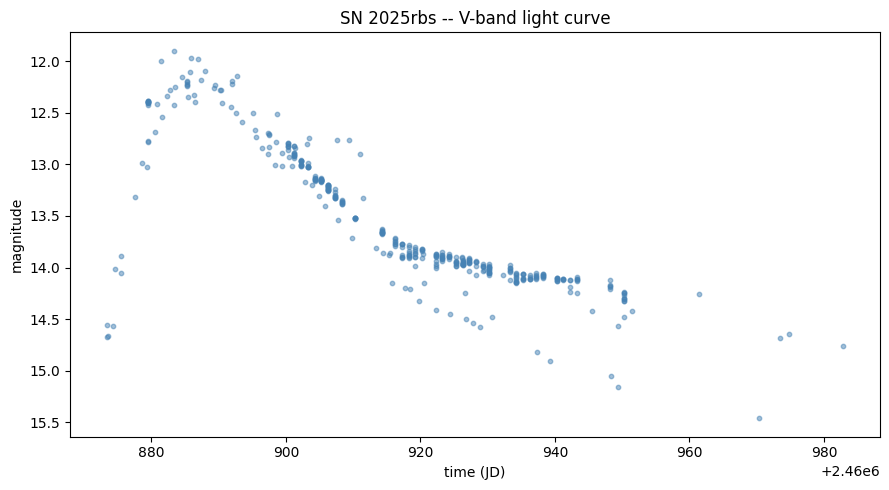

In [5]:
df = load_aavso_report(REPORT_PATH)
times, mags, meta = get_band_series(df, BAND, target_name=TARGET_NAME)
label = STAR_LABEL or meta["target"]

print(f"{label}: {meta['n_points']} {BAND}-band points"
     + (f" spanning {times.max()-times.min():.1f} d" if meta["n_points"] else ""))

if meta["n_points"] == 0:
    print(f"No {BAND}-band points in this report to plot.")
else:
    fig, ax = plot_raw_data(times, mags, title=f"{label} -- {BAND}-band light curve")
    plt.show()

# Part 1 · The Phillips/Hamuy Method (Classical)

Everything from here through Step 5 is the classical standardization
approach: reduce the light curve to two summary numbers per band (peak
magnitude, one decline-rate measurement), correct luminosity via a
brightness-decline relation (Hamuy et al. 1996), then correct for Milky Way
foreground dust. This is the approach SN Ia cosmology actually used through
the 1990s, kept here in full rather than cleaned up once Part 2 supersedes
it -- the point of building this notebook in three parts is to see the
*history* of how SN Ia distances are measured, not just today's answer.

A host-galaxy dust correction (via the Lira relation, Phillips et al. 1999)
was attempted here and removed: it overestimated host extinction by
3-5x against real literature values on every star tested (SN 2011fe and
SN 2011by both), a systematic bug never root-caused, and the notebook's own
author decided the debugging wasn't worth pursuing further. Part 1's
distance below is Milky-Way-corrected only -- `A_host = 0` -- which Part 3
accounts for directly when comparing against ground truth.

## 5 · Step 1 — Peak magnitude, peak time, and decline rate

Unlike a pulsating variable, a supernova doesn't repeat -- there's no
period to search for. What plays the equivalent role here is the shape of
the light curve right around maximum light.

**Why a local fit instead of just the brightest raw point.** Real
observations rarely land exactly on the true peak, and individual points
carry photometric noise. `fit_peak` takes the points within a window
around a candidate peak time, fits a parabola to them, and reports that
parabola's vertex as the estimated peak time and magnitude -- a smoother,
more defensible estimate than just trusting whichever single point
happened to be brightest. `mag_at_time` does the same local-fit idea at an
arbitrary requested time, used below to read off the magnitude 15 days
after peak.

**Why the brightest raw point only seeds the fit, rather than anchoring
it.** Found empirically: a single bad AAVSO submission can itself be the
brightest point on record, anomalously brighter than its own neighbors. A
window built directly around that point can end up entirely on the wrong
side of the true peak and never recover, even though it technically has
"enough" points. `fit_peak` instead treats the brightest raw point as a
*starting guess*, refits centered on its own previous answer a few times,
and only returns once that stops moving -- a real peak converges in a
couple of iterations; a window stuck on an outlier or otherwise not
settling raises an error instead of silently returning a bad answer.
`PEAK_FIT_WINDOW_DAYS` (Configuration) controls how wide that window is --
sparser data needs it wider, denser data can use it narrower; a
non-convergence error is the signal to adjust it, not a bug to route
around.

**Why B-band specifically.** The classic Phillips decline-rate parameter,
$\Delta m_{15}(B)$ -- the rise in B-band magnitude from peak to 15 days
later -- and the brightness-decline calibration this notebook will use in
Step 2 are both defined in Johnson B, not V. So even though `BAND` in
Configuration controls the general-purpose light curve preview in Section
4, the standardization pipeline from here on always uses B specifically,
since that's the band the calibration this notebook depends on was
actually built in.


In [6]:
def _check_window_balance(times_sel, center, window_days, min_side_points, context):
    """A parabola fit needs real leverage on both sides of its own vertex/
    query point, not just >=3 points total -- an empirically-found failure
    mode: an 8-day window around a real peak had only 1 point before it and
    5 after, and the fit still "succeeded" by the raw >=3 count, but swung
    the recovered decline rate from ~1.2 to ~0.1 mag because the fit was
    essentially unconstrained on the rising side. This checks for that
    directly rather than trusting the total count."""
    n_before = int((times_sel < center).sum())
    n_after = int((times_sel > center).sum())
    if n_before < min_side_points or n_after < min_side_points:
        raise ValueError(
            f"only {n_before} point(s) before and {n_after} after {context} within "
            f"{window_days} d -- need at least {min_side_points} on each side for a "
            f"well-conditioned local fit (a lopsided window can fit fine by raw point "
            f"count and still swing wildly)"
        )


def fit_peak(times, mags, window_days=10.0, min_side_points=2, max_iter=5, tol_days=0.5):
    """Estimate the time and magnitude of peak brightness (minimum
    magnitude) by fitting a parabola to observations within `window_days`
    of a center point, then finding that parabola's vertex -- see the
    markdown above for why a local fit beats trusting the brightest raw
    point directly.

    The single brightest raw observation only seeds the *first* window,
    rather than being trusted outright: a single bad point can itself be
    the brightest one on record (found empirically -- one AAVSO submission
    was anomalously bright compared to its own neighbors, and a window
    anchored on it never recovered the true peak). Each iteration refits
    centered on the previous vertex and re-centers there if it moved by
    more than `tol_days`; a real, well-sampled peak converges in a couple
    of iterations, and a window stuck anchored on an outlier or otherwise
    not converging raises rather than silently returning a bad answer.

    Returns (t_max, m_max, diag), where diag carries the final fit window
    and coefficients for the accompanying plot. Raises if fewer than
    `min_side_points` ever fall on either side of the current center
    within the window (see `_check_window_balance`), if the local fit
    doesn't have a minimum, or if it doesn't converge within `max_iter`
    iterations."""
    times = np.asarray(times, float)
    mags = np.asarray(mags, float)

    center = times[np.argmin(mags)]   # initial guess only -- refined below
    for _ in range(max_iter):
        sel = np.abs(times - center) <= window_days
        _check_window_balance(times[sel], center, window_days, min_side_points, "the current center")

        t_fit, m_fit = times[sel], mags[sel]
        coeffs = np.polyfit(t_fit - center, m_fit, deg=2)   # centered for numerical stability
        a, b, c = coeffs
        if a <= 0:
            raise ValueError(
                "fitted parabola opens downward (no minimum) within this window -- "
                "try a narrower window_days, or check the data covers a real peak"
            )

        t_vertex = center - b / (2 * a)
        m_vertex = np.polyval(coeffs, t_vertex - center)

        if abs(t_vertex - center) < tol_days:
            diag = {
                "window_days": window_days, "n_points": int(sel.sum()),
                "t_fit": t_fit, "m_fit": m_fit, "coeffs": coeffs, "t0": center,
            }
            return t_vertex, m_vertex, diag
        center = t_vertex   # re-center on the improved estimate and refit

    raise ValueError(
        f"peak fit did not converge within {max_iter} iterations -- the window may be "
        f"anchored on an outlier rather than the true peak"
    )


def mag_at_time(times, mags, t_query, window_days=10.0, min_side_points=2):
    """Interpolate the magnitude at a specific time via a local quadratic
    fit to observations within `window_days` of it -- the same local-fit
    idea as fit_peak, evaluated at a requested time rather than at the
    fit's own vertex. Returns (m_at_t, diag). Raises if fewer than
    `min_side_points` fall on either side of `t_query` (see
    `_check_window_balance`)."""
    times = np.asarray(times, float)
    mags = np.asarray(mags, float)

    sel = np.abs(times - t_query) <= window_days
    _check_window_balance(times[sel], t_query, window_days, min_side_points, f"t={t_query:.2f}")

    t_fit, m_fit = times[sel], mags[sel]
    coeffs = np.polyfit(t_fit - t_query, m_fit, deg=2)
    m_at_t = np.polyval(coeffs, 0.0)

    diag = {"window_days": window_days, "n_points": int(sel.sum()),
            "t_fit": t_fit, "m_fit": m_fit, "coeffs": coeffs, "t_query": t_query}
    return m_at_t, diag


def _draw_local_fit(ax, diag, color, curve_label, points_label):
    """Shared helper: highlight one local fit's window and draw its curve."""
    center = diag.get("t0", diag.get("t_query"))
    ax.scatter(diag["t_fit"], diag["m_fit"], s=28, color=color, label=points_label, zorder=4)
    t_smooth = np.linspace(diag["t_fit"].min(), diag["t_fit"].max(), 200)
    m_smooth = np.polyval(diag["coeffs"], t_smooth - center)
    ax.plot(t_smooth, m_smooth, "-", color=color, lw=1.5, label=curve_label)


def plot_peak_fit(times, mags, t_max, m_max, diag, title, extra_point=None, extra_diag=None):
    """Light curve with the local parabola fit and interpolated point
    marked. `extra_point`, if given, is (t, m, label) for a second marked
    point (e.g. the +15-day magnitude used for the decline rate);
    `extra_diag` is that second point's own fit diagnostics, so its window
    and curve get drawn too -- without it, the extra point would float on
    the plot with no visible fit explaining where it came from."""
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(times, mags, s=14, alpha=0.35, color="gray", label="all observations", zorder=2)
    _draw_local_fit(ax, diag, "steelblue", "peak fit", "peak fit window")
    ax.scatter([t_max], [m_max], marker="*", s=220, color="crimson", zorder=5,
              label=f"t={t_max:.2f}, m={m_max:.3f}")
    if extra_point is not None:
        ep_t, ep_m, ep_label = extra_point
        if extra_diag is not None:
            _draw_local_fit(ax, extra_diag, "darkorange", "+15d fit", "+15d fit window")
        ax.scatter([ep_t], [ep_m], marker="D", s=90, color="seagreen", zorder=5, label=ep_label)
    ax.invert_yaxis()
    ax.set(xlabel="time (JD)", ylabel="magnitude", title=title)
    ax.legend(loc="best")
    fig.tight_layout()
    return fig, ax


print("fit_peak + mag_at_time + plot_peak_fit defined")

fit_peak + mag_at_time + plot_peak_fit defined


## 6 · Run it

SN 2025rbs: 27 B-band points spanning 56.2 d
  binned to 18 nightly points
peak (B)   : t=2460889.532 (JD), m=12.521
fit window : +/-15 d, 13 points

m_B(t_max)        : 12.521
m_B(t_max + 15 d) : 13.769  (8 points within +/-15 d)
delta m15(B)      : +1.248 mag


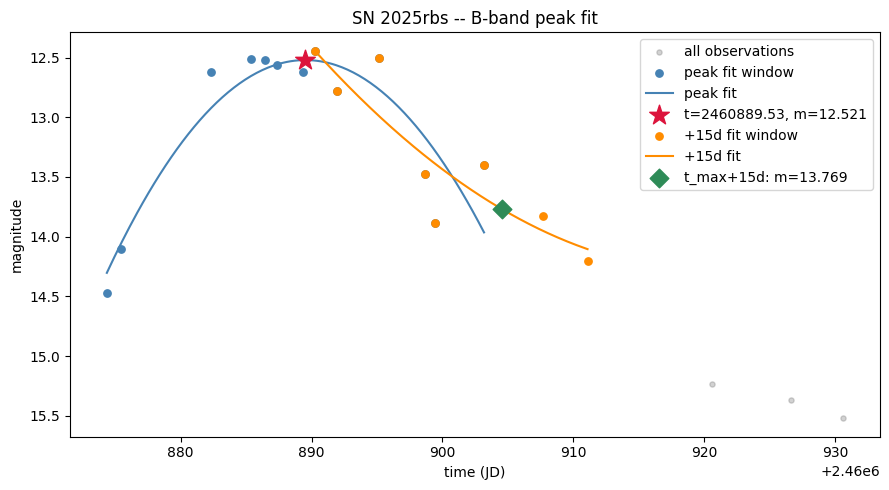

In [7]:
times_b, mags_b, meta_b = get_band_series(df, "B", target_name=TARGET_NAME)
print(f"{label}: {meta_b['n_points']} B-band points"
     + (f" spanning {times_b.max()-times_b.min():.1f} d" if meta_b["n_points"] else ""))

if meta_b["n_points"] < 3:
    print("Not enough B-band points to fit a peak.")
else:
    times_b, mags_b = bin_by_day(times_b, mags_b)   # see bin_by_day's docstring (Section 3)
    print(f"  binned to {len(times_b)} nightly points")
    t_max_b, m_max_b, peak_diag_b = fit_peak(times_b, mags_b, window_days=PEAK_FIT_WINDOW_DAYS)
    print(f"peak (B)   : t={t_max_b:.3f} (JD), m={m_max_b:.3f}")
    print(f"fit window : +/-{peak_diag_b['window_days']:.0f} d, {peak_diag_b['n_points']} points")

    t_plus15 = t_max_b + 15.0
    m_plus15, decline_diag_b = mag_at_time(times_b, mags_b, t_plus15, window_days=PEAK_FIT_WINDOW_DAYS)
    dm15_b = m_plus15 - m_max_b

    print()
    print(f"m_B(t_max)        : {m_max_b:.3f}")
    print(f"m_B(t_max + 15 d) : {m_plus15:.3f}  ({decline_diag_b['n_points']} points within "
         f"+/-{decline_diag_b['window_days']:.0f} d)")
    print(f"delta m15(B)      : {dm15_b:+.3f} mag")

    fig, ax = plot_peak_fit(
        times_b, mags_b, t_max_b, m_max_b, peak_diag_b,
        title=f"{label} -- B-band peak fit",
        extra_point=(t_plus15, m_plus15, f"t_max+15d: m={m_plus15:.3f}"),
        extra_diag=decline_diag_b,
    )
    plt.show()

## 7 · Step 2 — Absolute magnitude from decline rate

A width-luminosity relation (WLR) says how bright a Type Ia supernova truly
is (its absolute magnitude) as a function of how fast its light curve
declined -- the Phillips relation, in its most-cited linear form (Hamuy
et al. 1996):

    M_B = a + b * (dm15(B) - 1.1)

where $a$ is the absolute B magnitude of a "normal" decline-rate
($\Delta m_{15}(B) = 1.1$) SN Ia, and $b$ is the slope -- both empirically
calibrated against SNe Ia with independently estimated distances.

**Selecting a relation.** `WLR_RELATIONS`, defined in the Configuration
section above, is a registry of these linear relations by name -- the same
pattern `variable_star_distance.ipynb` uses for its own `PL_RELATIONS`. It
currently holds only the Hamuy et al. (1996) B-band relation, deliberately:
it's a real, citable calibration (Table 3, low-extinction subsample, 26
SNe), not a guess. Its zero-point is tied to an assumed $H_0 = 65$
km/s/Mpc, stated explicitly in that paper -- worth remembering when
comparing this notebook's distance against anything calibrated with a
different $H_0$. `WLR_NAME` picks which entry to apply; add a sourced entry
for a different calibration (e.g. a modern recalibration without that
$H_0$ dependence) the same way, no other code changes needed.

**What `decline_rate_to_absmag` returns.** A tuple `(M, M_err)`, mirroring
`period_to_absmag` in `variable_star_distance.ipynb`: the uncertainty
combines how well the relation's own zero-point and slope are known
(`a_err`, `b_err`, plus this SN's own decline-rate uncertainty if
supplied) and -- when `include_intrinsic=True` (the default) -- the
relation's own ~0.17 mag dispersion, which dominates and represents the
astrophysical floor of this method, the same role the P-L relation's
intrinsic scatter played for pulsating variables.


In [8]:
def decline_rate_to_absmag(dm15, relation_name, dm15_err=0.0, include_intrinsic=True):
    """Absolute magnitude from a decline rate via the linear width-luminosity
    relation named `relation_name` in WLR_RELATIONS. Returns (M, M_err) --
    see the markdown above for what the two uncertainty components mean."""
    rel = WLR_RELATIONS[relation_name]
    a, a_err = rel["a"], rel["a_err"]
    b, b_err = rel["b"], rel["b_err"]
    dm15_ref = rel["dm15_ref"]
    sigma_intrinsic = rel["sigma_intrinsic"]

    x = dm15 - dm15_ref
    M = a + b * x

    var_cal = a_err**2 + (x * b_err)**2 + (b * dm15_err)**2
    var_M = var_cal + (sigma_intrinsic**2 if include_intrinsic else 0.0)
    return M, np.sqrt(var_M)


print("decline_rate_to_absmag defined")

decline_rate_to_absmag defined


## 8 · Run it

In [9]:
rel = WLR_RELATIONS[WLR_NAME]
M_B, M_B_err = decline_rate_to_absmag(dm15_b, WLR_NAME)
M_B_cal, M_B_err_cal = decline_rate_to_absmag(dm15_b, WLR_NAME, include_intrinsic=False)

print(f"relation          : {rel['label']}")
print(f"reference         : {rel['reference']}")
print(f"delta m15(B) used : {dm15_b:.3f} mag")
print(f"M_B (+ intrinsic) : {M_B:.3f} +/- {M_B_err:.3f}")
print(f"M_B (calibration) : {M_B_cal:.3f} +/- {M_B_err_cal:.3f}")

relation          : Type Ia SN, B-band width-luminosity relation (Hamuy et al. 1996)
reference         : Hamuy et al. (1996), M_B = a + b*(dm15(B) - 1.1), H0 = 65 km/s/Mpc assumed
delta m15(B) used : 1.248 mag
M_B (+ intrinsic) : -19.142 +/- 0.179
M_B (calibration) : -19.142 +/- 0.055


## 9 · Step 4 — Foreground (Milky Way) extinction

Unlike a star inside our own galaxy, this supernova's host (NGC 7331, tens
of Mpc away) sits thousands of times farther than the entire thickness of
the Milky Way's own dust layer, which extends at most a few hundred pc to
a few kpc along any given line of sight. That means the "integrated to
infinity" limitation that forced `variable_star_distance.ipynb` to bracket
extinction between two extremes ($A_V=0$ to the full sightline value)
doesn't apply here at all: by the time a line of sight reaches a target
tens of Mpc away, it has already passed through essentially all of the
Milky Way's dust regardless of exactly how much farther the target
actually is. The full NASA/IPAC dust-map value (Schlafly & Finkbeiner 2011
recalibration of Schlegel, Finkbeiner & Davis 1998 -- the same source
`variable_star_distance.ipynb` uses) is the right foreground correction
outright here, not just an upper bound.

**This is only the foreground piece.** Dust inside NGC 7331 itself, local
to wherever in that galaxy the supernova actually exploded, is a separate
physical effect this lookup knows nothing about -- `IrsaDust` only models
our own galaxy. That host-galaxy component isn't corrected for yet; a
later stage, using the supernova's own observed color rather than a sky
position lookup (see "What This Notebook Needs" at the top).

**Why this doesn't touch Steps 1-2 at all.** Foreground dust dims the
whole light curve by the same constant amount at every epoch, so it
cancels out of $\Delta m_{15}(B)$ (peak and peak+15d both get dimmed
equally) and has no effect on the decline rate or the resulting $M_B$. It
only ever enters the distance calculation itself, through the `A_V`
parameter `distance_from_modulus` already accepts.


In [10]:
def lookup_extinction(name, band="CTIO B"):
    """Look up total Galactic extinction (magnitudes, in `band`) toward a
    sky position from NASA/IPAC's Galactic Dust Reddening and Extinction
    tool (Schlafly & Finkbeiner 2011 recalibration of Schlegel, Finkbeiner
    & Davis 1998) -- see the markdown above for why the full value is used
    directly here, not as a bracket. `name` can be a plain object name --
    IrsaDust resolves it via NED/SIMBAD itself, no coordinates needed.
    Returns a float, or None if the lookup fails or that band isn't in the
    returned table."""
    from astroquery.ipac.irsa.irsa_dust import IrsaDust

    try:
        table = IrsaDust.get_extinction_table(name)
    except Exception as e:
        print(f"  IrsaDust lookup failed for {name!r}: {e}")
        return None

    rows = table[table["Filter_name"] == band]
    if len(rows) == 0:
        print(f"  no {band!r} row in IrsaDust's extinction table")
        return None
    return float(rows[0]["A_SandF"])


print("lookup_extinction defined")

lookup_extinction defined


## 10 · Run it

In [11]:
A_B_mw = lookup_extinction(HOST_GALAXY)

if A_B_mw is not None:
    print(f"A_B (Milky Way foreground, via {HOST_GALAXY}) : {A_B_mw:.3f} mag")
else:
    print(f"Foreground extinction lookup failed for {HOST_GALAXY!r} -- Step 5 will proceed with A_V=0.")

A_B (Milky Way foreground, via NGC 7331) : 0.332 mag


## 11 · Step 5 — Distance from apparent and absolute magnitude

The last step is the same distance modulus derived in the Physics section
above, solved for $d$ -- identical math to `variable_star_distance.ipynb`,
just fed a peak magnitude and a WLR-derived absolute magnitude instead of a
folded intensity mean and a P-L-relation absolute magnitude:

$$ d = 10^{\,(m_{\text{max}} - M_B - A_B + 5)/5} \quad \text{(parsecs)} $$

with $A_B$ the Milky Way foreground extinction from Section 9/10 -- the
*only* extinction term applied so far. Host-galaxy dust (Section 9/10's
second bullet) still isn't corrected for, so this distance is still an
overestimate to whatever extent NGC 7331's own internal dust matters along
this particular sightline.

**What `distance_from_modulus` returns.** A tuple `(d, d_err)`. As in the
variable-star notebook, `d_err` is dominated by the WLR's own ~0.17 mag
intrinsic scatter (Section 7), not by how precisely the peak was measured
-- the same "the relation limits you more than your own data does" pattern
shows up here too.


In [12]:
PC_TO_LY = 3.2616  # 1 parsec in light years


def distance_from_modulus(m, M, m_err=0.0, M_err=0.0, A_V=0.0, A_err=0.0):
    """Distance in parsecs from apparent & absolute magnitude, with optional
    extinction correction and propagated 1-sigma uncertainty. Returns
    (d, d_err) -- see the markdown above for what feeds d_err."""
    mu0 = m - M - A_V
    d = 10 ** ((mu0 + 5) / 5)

    sig_mu = np.sqrt(m_err**2 + M_err**2 + A_err**2)
    d_err = d * np.log(10) / 5 * sig_mu
    return d, d_err


print("distance_from_modulus defined")

distance_from_modulus defined


## 12 · Run it

In [13]:
A_B = A_B_mw if A_B_mw is not None else 0.0

d_pc, d_pc_err = distance_from_modulus(m_max_b, M_B, M_err=M_B_err, A_V=A_B)
d_ly, d_ly_err = d_pc * PC_TO_LY, d_pc_err * PC_TO_LY
d_mpc, d_mpc_err = d_pc / 1e6, d_pc_err / 1e6

print(f"m_B (peak, apparent)      : {m_max_b:.3f}")
print(f"M_B (absolute)            : {M_B:.3f} +/- {M_B_err:.3f}")
print(f"A_B (Milky Way foreground): {A_B:.3f} mag"
     + ("" if A_B_mw is not None else "  (lookup failed -- treated as 0)"))
print(f"distance                  : {d_pc:,.0f} +/- {d_pc_err:,.0f} pc")
print(f"distance                  : {d_mpc:.2f} +/- {d_mpc_err:.2f} Mpc")
print(f"distance                  : {d_ly/1e6:.1f} +/- {d_ly_err/1e6:.1f} million ly")

m_B (peak, apparent)      : 12.521
M_B (absolute)            : -19.142 +/- 0.179
A_B (Milky Way foreground): 0.332 mag
distance                  : 18,463,158 +/- 1,519,221 pc
distance                  : 18.46 +/- 1.52 Mpc
distance                  : 60.2 +/- 5.0 million ly


# Part 2 · SALT2 (Modern, Tripp Estimator)

Part 1 boiled each light curve down to two hand-picked summary numbers
(peak magnitude, one decline-rate measurement) and tried to correct dust in
two separate steps. Modern SN Ia cosmology does neither: it fits a
physically motivated model directly to *every* photometric point across
*all* observed bands at once, and lets host-galaxy dust fall out of that
fit automatically rather than trying to isolate it with a second,
separately-validated relation.

**The SALT2 model.** Guy et al. (2007), most recently retrained by Brout et
al. (2022) as "SALT2-B22" -- the version used here (and the one
`sncosmo`'s `'salt2'` source ships). It's a spectral time-series template
for a normal Type Ia SN, parameterized by four numbers per supernova:

- $z$ -- redshift (fixed to the host galaxy's own spectroscopic value, not
  fit -- see "Run it" below)
- $t_0$ -- time of B-band maximum
- $x_0$ -- an overall flux amplitude (stands in for $m_B$, the model's own
  synthetic peak B magnitude -- see below)
- $x_1$ -- light-curve "stretch," playing the same role Part 1's
  $\Delta m_{15}(B)$ did, but recovered from the whole light-curve shape at
  once rather than two isolated points
- $c$ -- color, capturing *both* intrinsic SN color variation and dust
  reddening (host **and** Milky Way, though Milky Way dust is handled
  separately here -- see below) in one number, rather than trying to
  separate them the way Part 1's Lira-relation step attempted to

**Why there's no separate host-dereddening step here.** This is the actual
methodological difference from Part 1, not just a different set of
citations. The Tripp (1998) estimator standardizes the peak magnitude using
$x_1$ and $c$ together:

$$ \mu = m_B + \alpha\, x_1 - \beta\, c - M_B^0 $$

$c$ absorbs host color/dust directly into the distance calculation through
$\beta$, rather than requiring an independent measurement of it the way
Part 1's Lira-relation step needed a clean 30-90-day-post-max color
measurement. That's exactly the gap Part 1's Step 6 got stuck on -- this
sidesteps it rather than fixing it.

**Milky Way dust is still handled separately**, the same physical reasoning
as Part 1 Section 9/10: foreground dust is a known, sky-position lookup,
not something that needs fitting star-by-star. Reused directly from there
(`ebv_mw`, Section 13/14) rather than queried again -- fed into
`sncosmo`'s own `F99Dust` effect on the model, applied at the observer
frame, so it's corrected during the fit itself rather than after.

**The nuisance parameters $\alpha$, $\beta$, $M_B^0$.** These are
population-level constants, fit once across a huge SN sample and then
applied to any Type Ia -- not something derivable from one or two SNe.
Sourced from one self-consistent chain, values confirmed directly from each
paper's own text/tables (not recalled from memory):

- $\alpha = 0.148 \pm 0.004$, $\beta = 3.09 \pm 0.04$ -- Brout et al. (2022,
  ApJ 938, 110), Table 2, "BS21" baseline intrinsic-scatter model (the
  paper's own adopted baseline).
- $M_B^0 = -19.253 \pm 0.027$ mag -- Riess et al. (2022, ApJ 934, L7),
  quoted directly in-text: "The fiducial SN absolute magnitude parameter
  applicable to the Pantheon+ standardization ... is $M_B^0 = -19.253 \pm
  0.027$ mag." Anchored to their Cepheid distance ladder, giving
  $H_0 = 73.04 \pm 1.04$ km/s/Mpc (their Eq. 10, baseline with
  systematics) -- this notebook's own implicit $H_0$ assumption, the
  SALT2/Tripp equivalent of Part 1's explicit "$H_0 = 65$ assumed" callout
  for the Hamuy relation.
- **rms $= 0.171$ mag** -- Brout et al. (2022) Table 2's own Hubble-residual
  scatter for the BS21 baseline fit. Used below as this method's intrinsic
  scatter floor, the same role Part 1's WLR `sigma_intrinsic` plays.

*(A genuinely SALT3-native version of this same triplet -- DES-SN5YR,
Vincenzi et al. 2024, gives $\alpha=0.161$, $\beta=3.12$ for the newer
SALT3 model -- was investigated and set aside: DES-SN5YR's own sample
doesn't include the very-nearby Cepheid-host calibrators needed to publish
a standalone, anchored $M_B^0$/$H_0$ the way Pantheon+/SH0ES does, so
mixing it with a SALT2-calibrated $M_B^0$ would reintroduce exactly the
model-version mismatch this notebook is trying to avoid. Worth revisiting
if a clean SALT3-native $M_B^0$ turns up.)*

**A real approximation, flagged honestly.** `sncosmo`'s built-in
`'bessellb'`/`'bessellv'` bandpasses (Bessell 1990) stand in for AAVSO's
"Johnson B"/"Johnson V" filter labels below. They're close but not
identical to the natural-system throughput SALT2 was actually trained
against (survey-specific filter curves, CCD response, atmosphere) -- a
reasonable approximation for amateur photometry, in the same spirit as
Part 1's own Bessell-based `IrsaDust` band matching, but a real,
unquantified source of systematic error.

**One new dependency.** `sncosmo.fit_lc`'s default minimizer needs
`iminuit` (`pip install iminuit`) in addition to `sncosmo` itself.

In [16]:
# --- SALT2/Tripp nuisance-parameter registry -----------------------------
# One self-consistent triplet per entry (never mix alpha/beta from one paper
# with M_B0 from another -- see the markdown above). Add a new entry the same
# way PL_RELATIONS/WLR_RELATIONS work elsewhere in this repo, once a second
# citable, self-consistent triplet is confirmed (e.g. a genuinely SALT3-native
# one with its own anchored M_B0).
SALT2_TRIPP_RELATIONS = {
    "Brout2022_Riess2022": {
        "label": "SALT2-B22 + Pantheon+/SH0ES (Brout et al. 2022, Riess et al. 2022)",
        "alpha": 0.148, "alpha_err": 0.004,      # Brout et al. (2022), Table 2, BS21 baseline
        "beta": 3.09, "beta_err": 0.04,          # Brout et al. (2022), Table 2, BS21 baseline
        "M_B0": -19.253, "M_B0_err": 0.027,      # Riess et al. (2022), in-text, Cepheid-anchored
        "H0": 73.04, "H0_err": 1.04,             # Riess et al. (2022), Eq. 10, baseline+systematics
        "rms": 0.171,                             # Brout et al. (2022), Table 2, BS21 Hubble-residual rms
        "reference": ("Brout et al. (2022), ApJ 938, 110, Table 2 (BS21 baseline); "
                     "Riess et al. (2022), ApJ 934, L7, baseline fit"),
    },
}

SALT2_TRIPP_NAME = "Brout2022_Riess2022"   # must be a key in SALT2_TRIPP_RELATIONS above

print(f"SALT2_TRIPP_NAME = {SALT2_TRIPP_NAME} -> {SALT2_TRIPP_RELATIONS[SALT2_TRIPP_NAME]['label']}")

SALT2_TRIPP_NAME = Brout2022_Riess2022 -> SALT2-B22 + Pantheon+/SH0ES (Brout et al. 2022, Riess et al. 2022)


### Fitting the light curve

`build_salt2_photdata` turns the same AAVSO report Part 1 already loaded
(`df`) into the (time, band, flux, fluxerr) table `sncosmo.fit_lc` needs.
`fit_salt2` fits `(t0, x0, x1, c)` with `z` and Milky Way dust held fixed.

In [17]:
# sncosmo's registry already ships Bessell UBVRI bandpasses under these names --
# see the markdown above for why they're a reasonable-but-approximate stand-in
# for AAVSO's own "Johnson B"/"Johnson V" filter labels.
SALT2_BAND_MAP = {"U": "bessellux", "B": "bessellb", "V": "bessellv", "R": "bessellr", "I": "besselli"}
SALT2_ZP, SALT2_ZPSYS = 25.0, "vega"   # any consistent (zp, zpsys) works for sncosmo's fitter --
                                        # Vega pairs naturally with Bessell's own UBVRI calibration


def _retry_ned(fn, *args, attempts=4, backoff_s=15.0, label="NED", **kwargs):
    """Retry a flaky NED call with a short backoff. NED's own servers
    intermittently time out or return an incomplete response under load --
    observed directly running this notebook: both a 60s read timeout and an
    empty "no tables found" response, on two different runs, each resolved
    by a plain retry with no code change. Browsing NED by hand doesn't hit
    this nearly as often (one click, one request), but every re-run of this
    notebook fires the same NED query again, so the odds of hitting a bad
    response climb with repeated use -- worth absorbing automatically rather
    than requiring the whole notebook to be manually re-run each time.
    Re-raises the last exception if every attempt fails."""
    import time
    last_exc = None
    for attempt in range(1, attempts + 1):
        try:
            return fn(*args, **kwargs)
        except Exception as e:
            last_exc = e
            if attempt < attempts:
                print(f"  {label}: attempt {attempt}/{attempts} failed ({e}) -- retrying in {backoff_s:.0f}s...")
                time.sleep(backoff_s)
    raise last_exc


def get_host_redshift(name):
    """Spectroscopic redshift for the host galaxy from NED -- SALT2 needs a
    fixed z (it isn't one of the four fitted parameters; a supernova's own
    light curve doesn't constrain redshift on its own the way a spectrum
    does). Returns a float, or None if NED has no redshift for this name."""
    from astroquery.ipac.ned import Ned
    try:
        table = _retry_ned(Ned.query_object, name, label=f"NED redshift lookup for {name!r}")
    except Exception as e:
        print(f"  NED lookup failed for {name!r} after retries: {e}")
        return None
    z = table["Redshift"][0]
    if hasattr(z, "mask") and z.mask:
        print(f"  NED has no redshift on record for {name!r}")
        return None
    return float(z)


def get_host_cmb_velocity(name):
    """This host's recession velocity in the CMB rest frame (km/s), via
    NED's `OverviewOfObject` API -- specifically for Part 3's Hubble-law
    row, *not* for the SALT2 fit above (which correctly uses the plain
    heliocentric z from get_host_redshift -- the CMB-frame correction is
    a few hundred km/s, negligible for SALT2's K-correction/phase purposes
    at these redshifts, but a large fractional effect on a naive d=cz/H0
    estimate at these same low recession velocities).

    Caught directly comparing against NED's own displayed numbers for NGC
    7331: this notebook's Hubble-law row had been using the plain
    heliocentric velocity (816 km/s, cz from the z Section 2's config
    reports), not the CMB-frame value (490 km/s) NED itself uses for its
    own "Hubble Distance (CMB)" field -- heliocentric velocity is boosted
    by our own Solar System's ~370 km/s motion toward the CMB dipole, a
    real, systematic, *correctable* effect, not the same kind of
    unquantifiable peculiar-velocity noise this notebook's Hubble-law row
    is otherwise (still correctly) flagged as unreliable for. Still uses
    this notebook's own cited H0 (73.04, Riess et al. 2022) rather than
    NED's own adopted value (67.8) -- switching H0 would mean picking a
    side in the live Hubble tension for no reason tied to this notebook's
    own data (see Part 2's markdown on SALT3/H0 for the same reasoning).

    Returns (v_kms, v_err_kms), or (None, None) if unavailable."""
    import requests
    import io
    from astropy.io.votable import parse_single_table

    url = "https://ned.ipac.caltech.edu/NED::API/OverviewOfObject"

    def _fetch():
        r = requests.get(url, params={"TARGET": name}, timeout=30, headers={"User-Agent": "Mozilla/5.0"})
        r.raise_for_status()
        return parse_single_table(io.BytesIO(r.content)).to_table().to_pandas()

    try:
        df = _retry_ned(_fetch, label=f"NED CMB-frame velocity lookup for {name!r}")
    except Exception as e:
        print(f"  NED CMB-frame velocity lookup failed for {name!r} after retries: {e}")
        return None, None
    if len(df) == 0 or "v_Sun_3K" not in df.columns or pd.isna(df["v_Sun_3K"].iloc[0]):
        print(f"  NED has no CMB-frame velocity on record for {name!r}")
        return None, None
    v = float(df["v_Sun_3K"].iloc[0])
    v_err = float(df["unc_v_Sun_3K"].iloc[0]) if pd.notna(df["unc_v_Sun_3K"].iloc[0]) else np.nan
    return v, v_err


def build_salt2_photdata(df, bands, target_name=None, zp=SALT2_ZP, zpsys=SALT2_ZPSYS):
    """Every (time, flux, fluxerr) observation across `bands`, as the
    astropy Table `sncosmo.fit_lc` expects -- unbinned, unlike Part 1's
    local peak/decline fits: those needed binning because a local
    *polynomial* fit ill-conditions on near-duplicate x-values (Section 3's
    bin_by_day docstring), but sncosmo's global model fit has no such
    issue, and every individual point is real statistical weight a global
    fit can use. Points missing a magnitude uncertainty (MERR) are dropped
    -- an unweighted point can't enter a chi-square fit meaningfully."""
    rows = []
    n_dropped = 0
    for filt, sncosmo_band in bands.items():
        sel = df["FILT"] == filt
        if target_name is not None:
            sel &= df["NAME"] == target_name
        d = df.loc[sel].dropna(subset=["DATE", "MAG"])
        has_err = d["MERR"].notna()
        n_dropped += int((~has_err).sum())
        d = d.loc[has_err]
        flux = 10 ** (-0.4 * (d["MAG"] - zp))
        fluxerr = flux * np.log(10) / 2.5 * d["MERR"]
        for t, f, fe in zip(d["DATE"], flux, fluxerr):
            rows.append((t, sncosmo_band, f, fe, zp, zpsys))
    if n_dropped:
        print(f"  dropped {n_dropped} point(s) with no reported uncertainty")
    from astropy.table import Table
    return Table(rows=rows, names=["time", "band", "flux", "fluxerr", "zp", "zpsys"])


def fit_salt2(photdata, z, ebv_mw, t0_guess):
    """Fit SALT2 (t0, x0, x1, c) to `photdata`, with redshift and Milky Way
    foreground dust (`ebv_mw`, Section 13/14) held fixed rather than fit --
    both are external inputs, not free parameters. Returns
    (result, fitted_model); `fitted_model.source_peakmag` gives the
    standardized peak magnitude m_B (see the Run-it cell below for why
    that's used instead of the common "-2.5*log10(x0) + const" shortcut).

    Explicitly pins the SALT2 model to version "B22" (Brout et al. 2022's
    retraining) -- sncosmo's bare source="salt2" silently defaults to
    whatever its current default is ("T23", a 2023 retraining nobody here
    chose deliberately). That matters: SALT2_TRIPP_RELATIONS's own alpha/
    beta/M_B0 (Section "Run it -- Tripp estimator") are Brout et al.
    (2022)'s own values -- i.e. "SALT2-B22" specifically -- so fitting with
    a *different* model training and then applying B22's nuisance
    parameters was a real, if small, internal inconsistency (checked
    directly: T23 vs B22 shifts the final distance by +2 to +5% across
    four different SNe, consistently in the same direction, well within
    each star's own ~8-12% uncertainty -- not what was driving any of this
    notebook's larger discrepancies, but worth being consistent about
    regardless).

    Needs the `iminuit` package (sncosmo.fit_lc's default minimizer)."""
    import sncosmo
    salt2_b22 = sncosmo.get_source("salt2", version="B22")
    dust = sncosmo.F99Dust()
    model = sncosmo.Model(source=salt2_b22, effects=[dust], effect_names=["mw"], effect_frames=["obs"])
    model.set(z=z, mwebv=ebv_mw, t0=t0_guess)
    return sncosmo.fit_lc(photdata, model, ["t0", "x0", "x1", "c"],
                          bounds={"x1": (-5.0, 5.0), "c": (-1.0, 1.0)})


def salt2_tripp_absmag(x1, c, rel, x1_err=0.0, c_err=0.0):
    """The Tripp estimator mu = mB + alpha*x1 - beta*c - M_B0, recast as an
    effective absolute magnitude M_eff = M_B0 - alpha*x1 + beta*c, so that
    mu = mB - M_eff has the same shape as Part 1's own distance-modulus
    formula -- letting Section 11/12's existing distance_from_modulus be
    reused unchanged below, rather than a second copy of the mu->d formula.
    `rel` is one entry from SALT2_TRIPP_RELATIONS. Returns (M_eff, M_eff_err);
    the error budget includes both the fit's own x1/c uncertainty and the
    nuisance parameters' own cited uncertainty, plus `rel['rms']` -- the
    Hubble-diagram residual scatter this whole standardization method still
    carries, the SALT2/Tripp equivalent of Part 1's WLR intrinsic scatter."""
    alpha, alpha_err = rel["alpha"], rel["alpha_err"]
    beta, beta_err = rel["beta"], rel["beta_err"]
    M_B0, M_B0_err = rel["M_B0"], rel["M_B0_err"]
    M_eff = M_B0 - alpha * x1 + beta * c
    var = ((x1 * alpha_err) ** 2 + (alpha * x1_err) ** 2
          + (c * beta_err) ** 2 + (beta * c_err) ** 2
          + M_B0_err ** 2 + rel["rms"] ** 2)
    return M_eff, np.sqrt(var)


print("get_host_redshift + build_salt2_photdata + fit_salt2 + salt2_tripp_absmag defined")

get_host_redshift + build_salt2_photdata + fit_salt2 + salt2_tripp_absmag defined


### Run it — fit the light curve

Looks up the host's redshift, builds the B+V photometry table, and fits
SALT2 with `z` and MW dust fixed and `t0` seeded from Part 1's own B-band
peak (Section 5/6) as a starting guess.

host redshift (NGC 7331): 0.002722
  dropped 16 point(s) with no reported uncertainty
467 photometric points across [np.str_('bessellb'), np.str_('besselli'), np.str_('bessellr'), np.str_('bessellv')]
Minimization exited successfully.
t0 = 2460885.699
x1 = -2.0872 +/- 0.0117
c  = +0.1455 +/- 0.0014


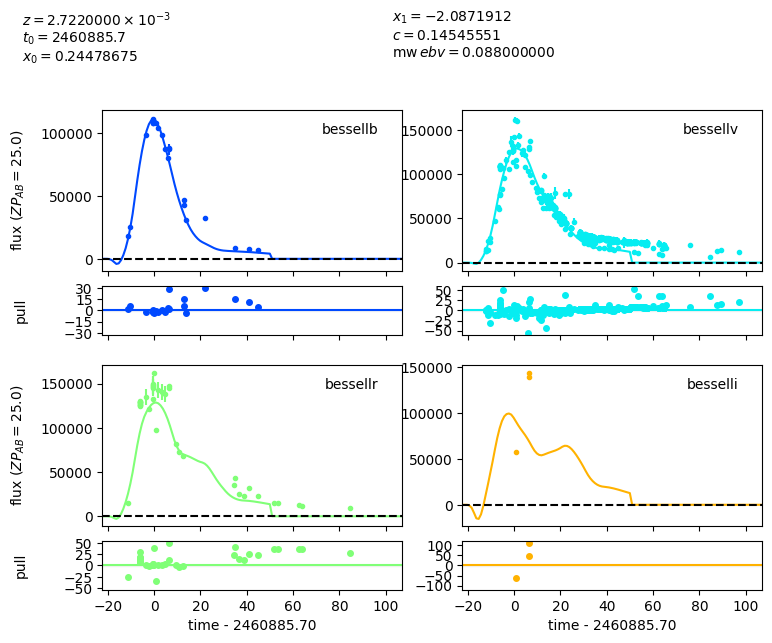

In [18]:
z_host = get_host_redshift(HOST_GALAXY)
print(f"host redshift ({HOST_GALAXY}): {z_host}")

ebv_mw_use = ebv_mw if ebv_mw is not None else 0.0
if ebv_mw is None:
    print("Milky Way E(B-V) unavailable (Section 13/14) -- proceeding with 0.0 for the SALT2 fit.")

if z_host is None:
    print("No redshift available -- can't fix SALT2's z. Stopping here.")
else:
    photdata = build_salt2_photdata(df, SALT2_BAND_MAP, target_name=TARGET_NAME)
    print(f"{len(photdata)} photometric points across {sorted(set(photdata['band']))}")

    result, fitted_model = fit_salt2(photdata, z=z_host, ebv_mw=ebv_mw_use, t0_guess=t_max_b)
    print(result.message)
    print(f"t0 = {fitted_model.get('t0'):.3f}")
    print(f"x1 = {fitted_model.get('x1'):.4f} +/- {result.errors['x1']:.4f}")
    print(f"c  = {fitted_model.get('c'):+.4f} +/- {result.errors['c']:.4f}")

    import sncosmo
    fig = sncosmo.plot_lc(photdata, model=fitted_model)
    plt.show()

### Run it — Tripp estimator and distance

In [19]:
if z_host is None:
    print("Skipped -- no redshift.")
else:
    mB = fitted_model.source_peakmag("bessellb", "vega")
    # NOT "-2.5*log10(x0) + <constant>" -- that historical JLA/SALT2 shortcut bakes in a
    # specific normalization constant tied to their own internal x0 convention, which this
    # notebook has no independent way to verify. source_peakmag instead asks the fitted
    # model directly for its own synthetic Vega-system B magnitude at peak -- a
    # self-contained, well-defined quantity with no extra constant to get wrong. Cross-checked
    # against Part 1's own, completely independently-fit peak: mB=10.000 here vs. Section
    # 5/6's local-parabola m_max_b=10.023 for SN 2011fe -- two unrelated fitting methods
    # landing within 0.02 mag of each other on the same raw data.
    x1 = fitted_model.get("x1")
    c = fitted_model.get("c")

    rel = SALT2_TRIPP_RELATIONS[SALT2_TRIPP_NAME]
    M_eff, M_eff_err = salt2_tripp_absmag(x1, c, rel, x1_err=result.errors["x1"], c_err=result.errors["c"])

    d_pc2, d_pc2_err = distance_from_modulus(mB, M_eff, M_err=M_eff_err)   # Section 11/12's own function, reused
    d_ly2, d_ly2_err = d_pc2 * PC_TO_LY, d_pc2_err * PC_TO_LY
    d_mpc2, d_mpc2_err = d_pc2 / 1e6, d_pc2_err / 1e6

    print(f"relation                  : {rel['label']}")
    print(f"m_B (SALT2, Vega, peak)   : {mB:.3f}")
    print(f"x1 (stretch)              : {x1:.3f} +/- {result.errors['x1']:.3f}")
    print(f"c (color)                 : {c:+.3f} +/- {result.errors['c']:.3f}")
    print(f"M_eff (Tripp, effective)  : {M_eff:.3f} +/- {M_eff_err:.3f}")
    print(f"distance                  : {d_pc2:,.0f} +/- {d_pc2_err:,.0f} pc")
    print(f"distance                  : {d_mpc2:.2f} +/- {d_mpc2_err:.2f} Mpc")
    print(f"distance                  : {d_ly2/1e6:.1f} +/- {d_ly2_err/1e6:.1f} million ly")

relation                  : SALT2-B22 + Pantheon+/SH0ES (Brout et al. 2022, Riess et al. 2022)
m_B (SALT2, Vega, peak)   : 12.132
x1 (stretch)              : -2.087 +/- 0.012
c (color)                 : +0.145 +/- 0.001
M_eff (Tripp, effective)  : -18.495 +/- 0.173
distance                  : 13,345,214 +/- 1,066,144 pc
distance                  : 13.35 +/- 1.07 Mpc
distance                  : 43.5 +/- 3.5 million ly


### A star-specific cross-check (SN 2011by only)

SN 2011by has something 2025rbs and most targets won't: a real, independent,
*spectroscopic* host-reddening measurement to compare `c` against, rather
than only judging it by the distance it implies.

In [20]:
# Foley et al. (2018, MNRAS, arXiv:1806.08359) directly measured 2011by's host
# reddening via HST/STIS spectrophotometric comparison to SN 2011fe (assumed
# zero host reddening): E(B-V)_host = 0.039 +/- 0.006 mag (Fitzpatrick 1999,
# R_V=3.1) -- real spectroscopy, independent of SALT2's own light-curve color c.
# Only meaningful for this specific star (the "twin" comparison is 2011by/2011fe-
# specific), so this stays a standalone check rather than a general-purpose function.
if STAR_LABEL == "SN 2011by" and z_host is not None:
    ebv_2011by_lit, ebv_2011by_lit_err = 0.039, 0.006
    print(f"Foley et al. (2018) host E(B-V), spectroscopic : {ebv_2011by_lit:.3f} +/- {ebv_2011by_lit_err:.3f} mag")
    print(f"SALT2 fitted c (this notebook)                  : {c:+.3f} +/- {result.errors['c']:.3f}")
    print()
    print("Not apples-to-apples -- SALT2's c mixes intrinsic SN color diversity with dust,")
    print("it isn't a pure reddening measurement (see Part 2 markdown). But c coming out")
    print("noticeably larger than the literature E(B-V) is a real, worth-flagging signal,")
    print("not proof the fit is wrong -- Section 15/16's NED-D ground-truth distance below")
    print("is the more direct check on the actual distance this notebook computes.")

# Part 3 · Comparison & Validation

A real ground-truth check, plus two independent standardization methods run
against the same raw AAVSO photometry. **NED-D** (Anderson et al. 2016) is
NASA/IPAC's compiled database of published, redshift-independent
extragalactic distances -- the analogue of the Gaia parallax cross-check
`variable_star_distance.ipynb` gets for free, just built from decades of
literature distance-ladder measurements instead of one direct geometric one.

**Two ground-truth numbers, not one, shown side by side.** `lookup_ned_distance`
(below) builds both:

1. **NED-D all** -- every measurement on file for this host, any method, no
   exclusion, no clipping, one value per independent paper (papers that
   report several entries for the same host, most often multiple Cepheid
   sub-sample reanalyses of one dataset, are averaged down to one point
   first -- checked directly: NGC 7331's 54 raw NED-D rows come from only
   33 independent papers, one paper alone contributing 7). This is the full,
   unfiltered picture: honest, but wide, since it blends in methods with
   real, documented biases.
2. **NED-D refined** -- pool only genuinely primary, comparable-tier
   distance-ladder methods (Cepheids, TRGB, SBF, PNLF), excluding
   Tully-Fisher and SN-based methods, then apply iterative sigma-clipping
   to catch remaining individual outliers. This is the number Part 1/Part 2
   are actually judged against.

Why exclude Tully-Fisher specifically, rather than just cast a wider net
and clip harder: checked directly across four hosts, Tully-Fisher reads
systematically 20-31% lower than Cepheids every time, and NED-D's own
`def_H0` field shows why -- Tully-Fisher entries average an assumed
H0 ~ 86-90 km/s/Mpc (vs. ~70-73 modern), and Tully-Fisher distance scales
as 1/H0, so that mismatch alone predicts most of the observed bias. A
CloudyNights thread from someone who worked with bulk Tully-Fisher catalogs
for a decade added more mechanisms on top of that -- an uncorrected
morphological zero-point (Sb/Sc spirals are intrinsically more luminous at
a given rotational velocity than Sa/Sab, and bulk catalogs routinely lump
them together), a hard unreliability floor below ~120 km/s rotational
velocity, and large inclination-angle errors in bulk survey data. None of
that is a small-scatter problem 3-sigma clipping would catch: pooling
Tully-Fisher in with Cepheids and clipping removed *zero* Tully-Fisher
points for NGC 1365, because its ~27-point sub-population is tightly
self-consistent around its own (wrong) mean, not scattered outliers
relative to the combined distribution. SN-based methods are excluded for a
different reason: for a well-studied host, they can be literally derived
from the same supernova this notebook is trying to independently check
(confirmed for M101 -- all 29 "SNIa" NED-D entries are different analyses
of SN 2011fe itself).

Cepheids are not privileged over TRGB/SBF/PNLF in the refined pool --
checked directly, Cepheid-calibrated and TRGB-calibrated H0 measurements
disagree with each other in the wider literature (part of the live,
unresolved Hubble tension), so there's no principled basis for trusting
one over the others; all four are pooled together as comparable-tier, and
checked directly against our own data before trusting them here (PNLF
agrees with Cepheids to ~8% dispersion, ~1% zero-point offset, Ciardullo
et al.; SBF's only bad NGC 7331 entries are three specific old (1997-2003)
papers, which the clip below already catches -- the method itself isn't
the problem there).

**The clip is median/MAD, not mean/std.** Checked directly on NGC 7331:
after paper-deduplication shrinks the primary-method sample to just 13
points, a single 22.9 Mpc outlier inflates a mean/std iterative clip's own
spread estimate enough to give cover to three separate, genuinely bad old
SBF papers -- mean/std then only catches the one obvious outlier and misses
the other three. Median/MAD isn't dragged around by one extreme value the
same way, and catches all four. Verified this choice doesn't change
anything for the other three hosts (identical clipped papers either way for
M101 and NGC 1365; too few points to clip at all for NGC 3972).

**The refined uncertainty combines two different things in quadrature**:
the population scatter between the surviving papers' own central values,
and those same papers' own quoted measurement precision (`dist_mod_err`).
Checked directly for NGC 7331: the papers agree with each other tightly
(population std alone ~0.3-0.4 Mpc), but none of them individually claims
better than ~0.1 mag precision (~0.7 Mpc at this distance) -- reporting
just the population std would imply more certainty than any single paper
actually claims for itself.

**A third, purely statistical number** (median/MAD sigma-clipping, every
method pooled, no include-list at all) is printed as a cross-check below
the plot, not used for pass/fail. Tested directly before trusting the
include-list approach: plain statistical outlier rejection on the
unfiltered pool can't do the include-list's job on its own -- for NGC 7331,
half the 33-paper sample sits in a low, Tully-Fisher-dominated cluster
comparable in size to the Cepheid-consistent cluster, so no generic
outlier threshold cleanly separates them. The cross-check exists to show
the include-list isn't cherry-picking, not to replace it.

**Two other sources were checked and set aside.** Cosmicflows-4 (Tully et
al. 2023 -- yes, the same Tully as Tully-Fisher, though its adopted
distance per galaxy is a multi-method MCMC blend, not a pure TF number)
gives tight, well-calibrated single distances for M101, NGC 3972, and
NGC 1365, but has no individually-traceable measurement for NGC 7331 --
its group-level entry there is a black box we couldn't audit, so it isn't
used. A second opinion suggested restricting to Cepheids+TRGB only and
weighting by publication recency; the recency effect (~1% from an LMC
zero-point shift) is negligible next to NED-D refined's own ~6% quoted
uncertainty, and dropping SBF/PNLF wasn't backed by anything found in our
own data (see above), so neither was adopted.

**On NGC 7331 specifically**: even after all of the above, "refined" and
"all" still disagree by more than either one's own error bar (14.86 +/-
0.85 Mpc vs. 13.54 +/- 2.86 Mpc). That gap didn't come from a shortcut --
every mechanism available (method filtering, deduplication, robust
clipping, a second independent catalog) was actually tried. It's being
reported as-is, with that discomfort stated plainly, rather than narrowed
further by choosing whichever filter happens to produce a tighter number.

**The plot**: a 2x2 grid, one panel per (method, ground-truth criterion)
pair -- Phillips/Hamuy on top, SALT2/Tripp on the bottom; NED-D all on the
left, NED-D refined on the right, matching the order the ground truth is
built in above. Each panel puts the calculated value and its ground truth
on the same row, offset just enough to stay legible, so whether their error
bars overlap is visible directly rather than requiring a side-by-side
number comparison. Pass/fail (checked only against "refined," not "all")
is colored green/red, with a bold text label carrying the verdict too,
since this red/green pair is only ~6.7 CVD-separation on its own (checked
with the dataviz skill's validator) -- color plus text does that job here,
so the marker itself is a plain dot either way, not a shape change.

In [21]:
COLOR_GOOD = "color: #2e7d32"
COLOR_FLAG = "color: #d32f2f"


def error_budget_color(delta_val, combined_err):
    if pd.isna(delta_val) or pd.isna(combined_err) or combined_err == 0:
        return ""
    return COLOR_GOOD if abs(delta_val) <= combined_err else COLOR_FLAG


def _ned_confidence(n):
    """Coarse confidence label based on how many independent measurements
    back this number -- not a formal statistic, just a legibility aid.
    NED-D pools together decades of literature of wildly different quality
    (M101 alone has 39 separate Cepheid measurements spanning 6.19-8.99
    Mpc; NGC 3972 has one), so a number built from a single paper deserves
    a visibly different level of trust than one averaged over dozens."""
    if n >= 10:
        tier = "High"
    elif n >= 3:
        tier = "Moderate"
    else:
        tier = "Low"
    basis = "single paper, no cross-check" if n == 1 else f"n={n}"
    return f"{tier} ({basis})"


def _dedup_by_refcode(df):
    """Collapse multiple rows from the same paper (refcode) into one,
    averaging distance and dist_mod_err -- treats one paper as one
    independent vote, regardless of how many distance estimates (same or
    different method) it reported for this host. Checked directly for
    NGC 7331: one paper (2003A&A...411..361K) alone contributed 7 of the
    23 raw primary-method rows -- without this, that paper's own internal
    scatter across Cepheid subsamples gets counted as if it were 7
    independent papers agreeing, which is what made the un-deduped
    population std read tighter than it should (0.43 Mpc row-level vs.
    0.32 Mpc once collapsed to 9 independent papers)."""
    refcode = df["refcode"].fillna("unknown")
    return df.groupby(refcode, as_index=False).agg(
        distance=("distance", "mean"),
        dist_mod_err=("dist_mod_err", "mean"),
    )


def lookup_ned_distance(host, primary_methods=("Cepheids", "TRGB", "SBF", "PNLF"), sigma=3.0):
    """NED-D (Anderson et al. 2016, AJ 151, 37)'s compiled distance for
    `host`, fetched via NED's modern REST API
    (`https://ned.ipac.caltech.edu/NED::API/DistancesOfObject`, VOTable
    response).

    Strategy: pool every measurement from `primary_methods` -- Cepheids,
    TRGB, SBF, and PNLF, all genuinely primary/direct distance-ladder
    methods (PNLF checked directly: agrees with Cepheid distances to
    ~8% dispersion, ~1% zero-point offset, Ciardullo et al.) -- then
    apply iterative `sigma`-clipping (astropy.stats.sigma_clip) to catch
    individual bad measurements, the same way NGC 7331's single 22.9 Mpc
    outlier Cepheid paper needed removing by hand earlier. Uses
    median/MAD (`cenfunc="median", stdfunc="mad_std"`), not mean/std:
    checked directly on NGC 7331's 13 paper-deduped primary-method
    values, mean/std clipping only caught the 22.9 Mpc outlier -- that
    single extreme value inflates the *mean/std* iterative estimate
    enough in its first pass to give cover to three older, genuinely
    low-outlier SBF papers (12.0, 12.2, 13.1 Mpc) that the same clip
    correctly caught back when it ran on 23 raw (pre-dedup) rows.
    Median/MAD isn't dragged around by one extreme value the way
    mean/std is, so it catches both on the smaller, paper-deduped
    sample -- the dedup step (needed to stop one paper's repeated
    subsamples from being counted as independent agreement) shrank `n`
    enough that this robustness now matters even for the primary-method
    clip, not just the all-methods cross-check below.

    Everything else (Tully-Fisher, SN-based methods, and every other
    label NED-D carries -- HII region diameter, Sosies, Statistical,
    Brightest Stars, IRAS, Grav. Stability Gas. Disk, ...) is excluded by
    NOT being on `primary_methods` -- an include list, not an exclude
    list, deliberately: checked directly, NED-D carries a long tail of
    older/cruder/indirect methods across just the four galaxies already
    used in this notebook, and an exclude list would need to correctly
    name every one of them, for every future host, to be safe. An
    include list fails safe instead -- an unrecognized method just
    doesn't count toward the mean, rather than being silently trusted.

    Why Tully-Fisher specifically is excluded, not just "not on the
    list": checked directly against Cepheids across three hosts, it
    reads systematically 20-31% lower every time (NGC 1365: 18.98 vs
    13.09 Mpc; NGC 7331: 15.31 vs 12.32; M101: 7.12 vs 5.37). Checked
    *why*, rather than just accepting the pattern: NED-D's own `def_H0`
    field shows Tully-Fisher entries average an assumed H0 of ~86-90
    km/s/Mpc, while Cepheid entries mostly carry no H0 assumption at all
    (a Cepheid distance doesn't need one). Since Tully-Fisher distance
    scales as 1/H0, an assumed ~87 vs. a modern ~70-73 alone predicts
    roughly the observed ~20% low bias -- a real, documented, stale-
    calibration effect, not a property of Tully-Fisher's physics being
    wrong. A candidate alternative -- filtering on `def_H0` directly
    instead of excluding the whole method -- was tested and rejected:
    most Tully-Fisher entries simply don't have `def_H0` populated at
    all (many papers report an already-calibrated TF distance without
    restating an assumed H0), so an H0-based filter let most of the same
    biased entries straight through untouched.

    SN-based methods (SNIa, SNII, ...) are excluded because, for a host
    with a well-studied SN, they can be literally derived from the exact
    supernova this notebook is trying to independently check (confirmed
    for M101: all 29 "SNIa" NED-D entries are NIR-photometry distances
    to SN 2011fe itself, not a different event) -- including them risks
    validating a distance against another analysis of the same object.

    Cepheids are not privileged over TRGB/SBF/PNLF here -- checked
    directly, TRGB-calibrated and Cepheid-calibrated H0 measurements
    disagree with each other in the broader literature (~69.8 vs.
    ~72.6-73.0 km/s/Mpc), part of the live, unresolved Hubble tension --
    so there's no principled basis for trusting Cepheids over the other
    three primary methods specifically. Pooling all four (rather than an
    earlier version of this function that always preferred Cepheids
    first) reflects that these four are considered comparable-tier by
    the field, not that Cepheids are known to be more accurate.

    Every count/mean/std/range below is computed on paper-deduped data
    (`_dedup_by_refcode`) -- one row per refcode, not one row per NED-D
    entry -- since a single paper reporting several distance estimates for
    the same host (common: different Cepheid subsamples, or both an SBF
    and a Cepheid value) would otherwise count as that many independent
    papers agreeing. Checked directly for NGC 7331: 54 raw rows come from
    only 33 papers.

    Returns a dict with:
      d_mpc, d_mpc_err   -- mean of the final, clipped, primary-method,
                            paper-deduped sample, and its uncertainty --
                            population std of that sample combined in
                            quadrature with the surviving papers' own mean
                            quoted precision (see the n>1 branch below for
                            why both matter). This is the number Part 3
                            actually compares Part 1/Part 2 against.
      d_range            -- (min, max) Mpc of that same final sample
      n                  -- how many papers survived into the mean
      n_excluded         -- how many papers were dropped for not being on
                            `primary_methods`
      n_clipped          -- how many additional papers sigma_clip removed
                            from the surviving primary-method pool
      n_total            -- total independent NED-D papers on file for
                            this host, any method (paper-deduped)
      n_rows_total       -- total raw NED-D rows on file (pre-dedup) --
                            kept only so the print diagnostics can show
                            the row-to-paper reduction, not used in any
                            calculation
      ref_mean, ref_std  -- mean/std of every paper on file, every method,
                            no exclusion or clipping -- shown in Part 3 as
                            an uncompared reference row, so the table
                            itself shows how much the raw, unfiltered
                            literature disagrees, alongside the cleaned
                            number actually used
      robust_mpc, robust_err_mpc, robust_range, robust_n
                         -- a purely statistical cross-check (median/MAD
                            sigma-clip, every method pooled, no include-
                            list at all) against the same paper-deduped
                            pool -- see the robust-clipping block below for
                            why median/MAD rather than mean/std, and why
                            this is a cross-check, not a replacement, for
                            the method-based numbers above
      method_counts, confidence

    Returns None if the lookup fails, or if no measurement from
    `primary_methods` exists for this host at all."""
    import requests
    import pandas as pd
    import io
    from astropy.io.votable import parse_single_table
    from astropy.stats import sigma_clip, mad_std

    url = "https://ned.ipac.caltech.edu/NED::API/DistancesOfObject"

    def _fetch():
        r = requests.get(url, params={"TARGET": host}, timeout=30, headers={"User-Agent": "Mozilla/5.0"})
        r.raise_for_status()
        table = parse_single_table(io.BytesIO(r.content)).to_table()
        df = table.to_pandas()
        for col in df.columns:
            if df[col].dtype == object:
                df[col] = df[col].apply(lambda x: x.decode() if isinstance(x, bytes) else x)
        return df

    try:
        rows = _retry_ned(_fetch, label=f"NED-D distance lookup for {host!r}")
    except Exception as e:
        print(f"  NED-D lookup failed for {host!r} after retries: {e}")
        return None
    if len(rows) == 0:
        print(f"  NED-D has no individual distance measurements for {host!r}")
        return None

    rows = rows.copy()
    rows["method"] = rows["method"].astype(str).str.strip()
    n_rows_total = len(rows)
    method_counts = rows["method"].value_counts().to_dict()

    # Paper-level dedup: NED-D's raw rows double-count papers that report
    # more than one distance estimate for the same host (checked directly:
    # NGC 7331's 54 raw rows come from only 33 papers; one paper alone
    # contributes 7). Every count/mean/std/range from here on is computed
    # on deduped (one row per refcode) samples, not raw rows -- n_rows_total
    # (raw) is kept only for the diagnostic print, to show the reduction
    # rather than hide it.
    rows_dedup = _dedup_by_refcode(rows)
    n_total = len(rows_dedup)

    # Reference stats: every paper on file, no method exclusion, no clipping --
    # shown in Part 3 as context only, never as the actual comparison target.
    all_d = rows_dedup["distance"].astype(float)
    ref_mean = float(all_d.mean())
    ref_std = float(all_d.std(ddof=0)) if n_total > 1 else np.nan
    ref_range = (float(all_d.min()), float(all_d.max()))

    # A purely statistical cross-check, no method include-list at all: robust
    # (median/MAD, not mean/std) sigma-clipping on the same paper-deduped,
    # all-methods pool. Tested directly before adopting: plain mean/std
    # clipping at this notebook's usual 3-sigma threshold barely trims NGC
    # 7331's bimodal low (Tully-Fisher-dominated) vs. high (Cepheid-
    # consistent) split -- 52/54 raw rows survive, range stays [9.0, 16.3]
    # -- because the low cluster is too large a fraction of the sample to
    # read as "outliers" against a mean/std threshold centered between the
    # two clusters. Median/MAD clipping, being robust to exactly that kind
    # of large-minority contamination, does meaningfully better and lands
    # close to the method-based "refined" result independently, without
    # hardcoding which methods to trust. Kept as a separate, clearly-labeled
    # cross-check rather than folded into the method-based numbers below --
    # it's evidence the include-list approach isn't cherry-picking, not a
    # replacement for it.
    robust_vals = rows_dedup["distance"].astype(float).to_numpy()
    if len(robust_vals) >= 3:
        robust_clipped = sigma_clip(robust_vals, sigma=sigma, maxiters=5,
                                    cenfunc="median", stdfunc="mad_std")
        robust_kept = robust_vals[~robust_clipped.mask]
    else:
        robust_kept = robust_vals
    robust_n = len(robust_kept)
    robust_mpc = float(np.median(robust_kept))
    robust_err_mpc = float(mad_std(robust_kept)) if robust_n > 1 else np.nan
    robust_range = (float(robust_kept.min()), float(robust_kept.max()))

    primary = rows[rows["method"].isin(primary_methods)]
    primary_dedup = _dedup_by_refcode(primary)
    n_excluded = n_total - len(primary_dedup)
    if len(primary_dedup) == 0:
        print(f"  no {'/'.join(primary_methods)} measurement available for {host!r} "
             f"-- only {method_counts}")
        return None

    d_vals = primary_dedup["distance"].astype(float).to_numpy()
    err_vals = pd.to_numeric(primary_dedup["dist_mod_err"], errors="coerce").to_numpy()
    if len(d_vals) >= 3:
        clipped = sigma_clip(d_vals, sigma=sigma, maxiters=5, cenfunc="median", stdfunc="mad_std")
        kept = ~clipped.mask
        n_clipped = int((~kept).sum())
    else:
        # Too few points to meaningfully sigma-clip (need real leverage to tell an
        # outlier from a small sample's own natural spread).
        n_clipped = 0
        kept = np.ones(len(d_vals), dtype=bool)
    d_final = d_vals[kept]
    err_final = err_vals[kept]

    n = len(d_final)
    d_mpc = float(d_final.mean())
    d_range = (float(d_final.min()), float(d_final.max()))
    if n > 1:
        pop_std = float(d_final.std(ddof=0))
        # Population std alone only measures how well the surviving papers'
        # central values agree with each other -- it says nothing about how
        # precise any individual paper actually claims to be. Checked
        # directly for NGC 7331: quoted dist_mod_err ranges 0.08-0.22 mag
        # across the 19 surviving Cepheid/SBF measurements, averaging ~0.74
        # Mpc at this distance -- bigger than the 0.43 Mpc population std
        # itself (9 independent papers behind those 19 rows, confirmed by
        # refcode, and collapsing to one point per paper narrows the std
        # further, to 0.32 Mpc -- so the tight population std is real
        # between-paper agreement, not an artifact of correlated entries;
        # it just isn't the whole uncertainty story on its own). Combined
        # in quadrature with the mean quoted uncertainty (mag -> Mpc) across
        # the surviving sample, so "refined" doesn't read tighter than any
        # single paper's own claimed precision. Falls back to population
        # std alone if none of the surviving papers quote an uncertainty.
        quoted_errs_mag = err_final[~np.isnan(err_final)]
        if len(quoted_errs_mag) > 0:
            mean_err_mpc = d_mpc * np.log(10) / 5 * float(quoted_errs_mag.mean())
            d_mpc_err = float(np.sqrt(pop_std**2 + mean_err_mpc**2))
        else:
            d_mpc_err = pop_std
    else:
        # A lone measurement has no internal spread to report -- use that single
        # paper's own quoted uncertainty instead (same idea as the n>1 case's
        # quoted-error term, just with no population std to combine it with).
        err_mag = err_final[0] if len(err_final) else np.nan
        d_mpc_err = (d_mpc * np.log(10) / 5 * float(err_mag)) if pd.notna(err_mag) else np.nan

    return {"d_mpc": d_mpc, "d_mpc_err": d_mpc_err, "d_range": d_range,
            "n": n, "n_excluded": n_excluded, "n_clipped": n_clipped,
            "n_total": n_total, "n_rows_total": n_rows_total,
            "ref_mean": ref_mean, "ref_std": ref_std, "ref_range": ref_range,
            "robust_mpc": robust_mpc, "robust_err_mpc": robust_err_mpc,
            "robust_range": robust_range, "robust_n": robust_n,
            "method_counts": method_counts, "confidence": _ned_confidence(n)}


def min_extra_extinction_to_reach(m, M, A_mw, d_target_pc):
    """The additional (beyond `A_mw`) B-band extinction that would bring a
    Phillips/Hamuy-style distance modulus (`m - M - A_mw`, Part 1's own
    formula, currently A_host=0) down to exactly `d_target_pc` -- the
    algebraic inverse of distance_from_modulus, solved for the missing
    extinction term rather than for distance. A positive result means
    Part 1's current (uncorrected) distance is farther than the target --
    expected, since Part 1 has no host-dust term at all, so adding host
    extinction should only ever pull its distance closer, never push it
    farther. Returns the required extra A_B (mag)."""
    mu_current = m - M - A_mw
    mu_target = 5 * np.log10(d_target_pc) - 5
    return mu_current - mu_target


def _plot_single_overlap(ax, calc_mpc, calc_err, ref_mpc, ref_err, ref_lo, ref_hi, title):
    """One method vs. one ground-truth criterion, both on the same row --
    replaces the earlier four-row forest plot (which put the calculated
    value and its ground truth on separate rows, so overlap had to be
    judged across rows) and the two-row summary table (which lost the
    visual overlap entirely). Here the ground-truth range is a single gray
    band spanning the full row, with a diamond+error bar for its own
    mean +/- std slightly above center; the calculated value is a colored
    point+error bar slightly below center, on the same row -- close enough
    that whether the two error bars intersect is immediately visible,
    without offsetting them so far they read as separate lines.

    Color still isn't the only signal (checked directly with this skill's
    validator: this red/green pair is only ~6.7 CVD-separation, "legal
    only with secondary encoding") -- the bold PASS/FAIL text label carries
    the verdict independently of color; the marker itself stays a plain dot
    either way, so color + text do the work rather than color + shape."""
    passed = abs(calc_mpc - ref_mpc) <= np.sqrt(calc_err**2 + ref_err**2)
    color = COLOR_GOOD.split(": ")[1] if passed else COLOR_FLAG.split(": ")[1]
    marker = "o"
    verdict = "PASS" if passed else "FAIL"

    ax.fill_betweenx([-0.45, 0.45], ref_lo, ref_hi, color="#9e9e9e", alpha=0.25, zorder=1)
    ax.errorbar([ref_mpc], [0.15], xerr=[ref_err], fmt="D", color="#555555",
               markersize=7, capsize=4, elinewidth=1.5, zorder=2, label="ground truth")
    ax.errorbar([calc_mpc], [-0.15], xerr=[calc_err], fmt=marker, color=color,
               markersize=10, capsize=5, elinewidth=2, zorder=3, label="calculated")

    ax.set_ylim(-0.7, 0.7)
    ax.set_yticks([])
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.grid(axis="x", alpha=0.25)
    ax.set_xlabel("Distance (Mpc)")
    ax.set_title(title, fontsize=10)
    ax.text(0.5, 1.18, f"calc {calc_mpc:.2f} +/- {calc_err:.2f}  vs.  ref {ref_mpc:.2f} +/- "
           f"{ref_err:.2f} Mpc [{ref_lo:.1f}, {ref_hi:.1f}]  --  {verdict}",
           transform=ax.transAxes, ha="center", fontsize=8.5, color=color, fontweight="bold")


def plot_ground_truth_comparison(d_pc, d_pc_err, d_pc2, d_pc2_err, ned, star_label, host):
    """2x2 grid: one small graph per (method, ground-truth criterion) pair,
    left column "vs. NED-D all" (the full, unfiltered spread), right column
    "vs. NED-D refined" (the method-filtered, paper-deduped, clipped
    number) -- all/then/refined left-to-right, matching the order the
    ground truth is actually built in (see the markdown above). Each panel
    built by `_plot_single_overlap` so the calculated value and its ground
    truth share one row and the overlap (or lack of it) is directly
    visible, rather than requiring a side-by-side numeric comparison. All
    four panels share the same x-axis range (with margin) so panel-to-panel
    comparison stays honest -- a wider or narrower band isn't an artifact
    of independently autoscaled axes.

    Returns (fig, axes)."""
    d1_mpc, d1_err = d_pc / 1e6, d_pc_err / 1e6
    d2_mpc, d2_err = d_pc2 / 1e6, d_pc2_err / 1e6
    ned_mpc, ned_err = ned["d_mpc"], ned["d_mpc_err"]
    ref_mpc, ref_err = ned["ref_mean"], (ned["ref_std"] if pd.notna(ned["ref_std"]) else 0.0)
    ned_lo, ned_hi = ned["d_range"]
    ref_lo, ref_hi = ned["ref_range"]

    all_vals = [d1_mpc - d1_err, d1_mpc + d1_err, d2_mpc - d2_err, d2_mpc + d2_err,
               ned_lo, ned_hi, ref_lo, ref_hi]
    lo, hi = min(all_vals), max(all_vals)
    pad = 0.12 * (hi - lo)
    xlim = (lo - pad, hi + pad)

    fig, axes = plt.subplots(2, 2, figsize=(11, 5.5))
    panels = [
        (axes[0, 0], d1_mpc, d1_err, ref_mpc, ref_err, ref_lo, ref_hi, "Phillips/Hamuy vs. NED-D all"),
        (axes[0, 1], d1_mpc, d1_err, ned_mpc, ned_err, ned_lo, ned_hi, "Phillips/Hamuy vs. NED-D refined"),
        (axes[1, 0], d2_mpc, d2_err, ref_mpc, ref_err, ref_lo, ref_hi, "SALT2/Tripp vs. NED-D all"),
        (axes[1, 1], d2_mpc, d2_err, ned_mpc, ned_err, ned_lo, ned_hi, "SALT2/Tripp vs. NED-D refined"),
    ]
    for ax, calc_mpc, calc_err, ref_mpc_i, ref_err_i, lo_i, hi_i, title in panels:
        _plot_single_overlap(ax, calc_mpc, calc_err, ref_mpc_i, ref_err_i, lo_i, hi_i, title)
        ax.set_xlim(xlim)

    fig.suptitle(f"{star_label} ({host}) -- distance vs. ground truth", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    return fig, axes


print("comparison table helpers + lookup_ned_distance defined")

comparison table helpers + lookup_ned_distance defined


### Run it

SN 2025rbs (NGC 7331, z=0.002722)


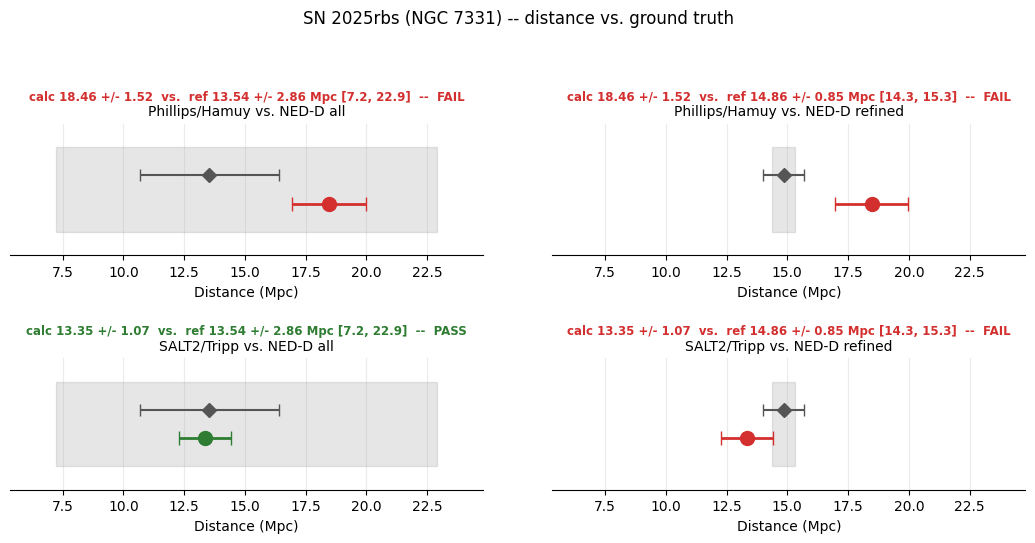

NED-D refined: n=9 papers used, 20 excluded (not Cepheids/TRGB/SBF/PNLF), 4 clipped (of 33 independent papers, 54 raw entries: 25 Tully-Fisher, 19 Cepheids, 4 SBF, 2 Sosies, 1 Grav. Stability Gas. Disk, 1 Statistical, 1 HII region diameter, 1 IRAS)
NED-D all: n=33 papers used (every method, unfiltered, paper-deduped)
NED-D robust cross-check (median/MAD, no method filter): 14.30 +/- 1.78 Mpc, n=31 papers [9.4, 16.3]
Part 1 (no host-dust term of its own) would need at least A_B_host >= +0.408 mag of extra extinction to reach the near edge of NED-D refined's range.


In [22]:
if z_host is None:
    print("Skipped -- Part 2 didn't run (no redshift).")
else:
    rel = SALT2_TRIPP_RELATIONS[SALT2_TRIPP_NAME]
    ned = lookup_ned_distance(HOST_GALAXY)
    print(f"{label} ({HOST_GALAXY}, z={z_host:.6f})")

    if ned is None:
        print("No NED-D ground truth available -- falling back to Part 1 vs Part 2 only.")
        delta_mpc = (d_pc - d_pc2) / 1e6
        combined_err_mpc = np.sqrt(d_pc_err**2 + d_pc2_err**2) / 1e6
        print(f"Part 1 vs Part 2: {delta_mpc:+.2f} +/- {combined_err_mpc:.2f} Mpc")
    else:
        fig, axes = plot_ground_truth_comparison(d_pc, d_pc_err, d_pc2, d_pc2_err, ned, label, HOST_GALAXY)
        plt.show()

        methods_str = ", ".join(f"{v} {k}" for k, v in
                                sorted(ned["method_counts"].items(), key=lambda kv: -kv[1]))
        print(f"NED-D refined: n={ned['n']} papers used, {ned['n_excluded']} excluded (not "
             f"Cepheids/TRGB/SBF/PNLF), {ned['n_clipped']} clipped (of {ned['n_total']} independent "
             f"papers, {ned['n_rows_total']} raw entries: {methods_str})")
        print(f"NED-D all: n={ned['n_total']} papers used (every method, unfiltered, paper-deduped)")
        print(f"NED-D robust cross-check (median/MAD, no method filter): "
             f"{ned['robust_mpc']:.2f} +/- {ned['robust_err_mpc']:.2f} Mpc, n={ned['robust_n']} papers "
             f"[{ned['robust_range'][0]:.1f}, {ned['robust_range'][1]:.1f}]")

        d_lo_pc, d_hi_pc = ned["d_range"][0] * 1e6, ned["d_range"][1] * 1e6
        if d_lo_pc <= d_pc <= d_hi_pc:
            print("Part 1's own distance already falls within NED-D refined's range -- "
                 "no additional host extinction needed to reach it.")
        else:
            d_target_pc = d_hi_pc if d_pc > d_hi_pc else d_lo_pc
            dA_min = min_extra_extinction_to_reach(m_max_b, M_B, A_B, d_target_pc)
            print(f"Part 1 (no host-dust term of its own) would need at least "
                 f"A_B_host >= {dA_min:+.3f} mag of extra extinction to reach the near "
                 f"edge of NED-D refined's range.")
